In [60]:
!pip install shap

In [88]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=8ee47129ec289de69e339924add280e29055c5340b7e763fac12f3f1f8b8e56c
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [89]:
from lime.lime_tabular import LimeTabularExplainer

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

In [62]:
#read dataset
df = pd.read_csv("/content/diabetes_012_health_indicators_BRFSS2015.csv (1).zip")

In [63]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(253680, 22)


In [64]:
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0      

In [65]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [66]:
print("\nTarget Distribution:")
print(df["Diabetes_012"].value_counts())


Target Distribution:
Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64


In [67]:
#duplicates
df = df.drop_duplicates().sample(20000, random_state=42)

In [68]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']


In [69]:
#rtrain & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [70]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [71]:
#scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [72]:
# 5.XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss'
)

In [73]:
#training model by using weights
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [74]:
# 7. expectation
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)

In [75]:
# 8.evaluation
print("\n" + "="*30)
print("Evaluation Results of the Developed XGBoost Model")
print("="*30)
print(f"Accuracy Score: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"ROC AUC Score (OVR): {roc_auc_score(y_test, xgb_proba, multi_class='ovr'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))



Evaluation Results of the Developed XGBoost Model
Accuracy Score: 0.6705
ROC AUC Score (OVR): 0.7259

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.69      0.79      3315
         1.0       0.03      0.11      0.04        81
         2.0       0.33      0.65      0.44       604

    accuracy                           0.67      4000
   macro avg       0.43      0.48      0.42      4000
weighted avg       0.82      0.67      0.72      4000



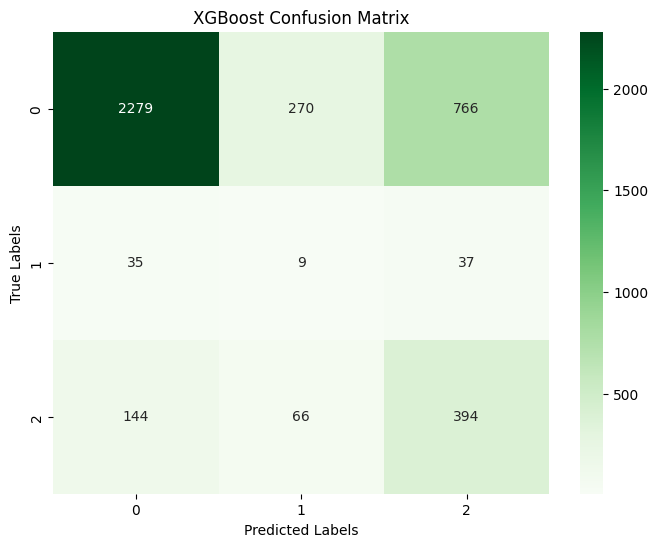

In [76]:
# 9.(Confusion Matrix)
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

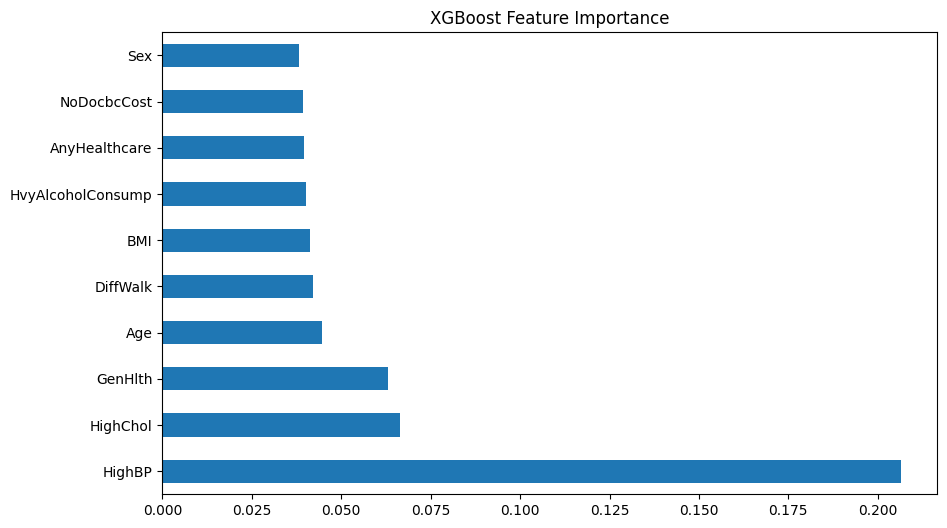

In [77]:
# Feature Importance (For XGBoost)
plt.figure(figsize=(10,6))
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh') # Show top 10 features
plt.title("XGBoost Feature Importance")
plt.show()

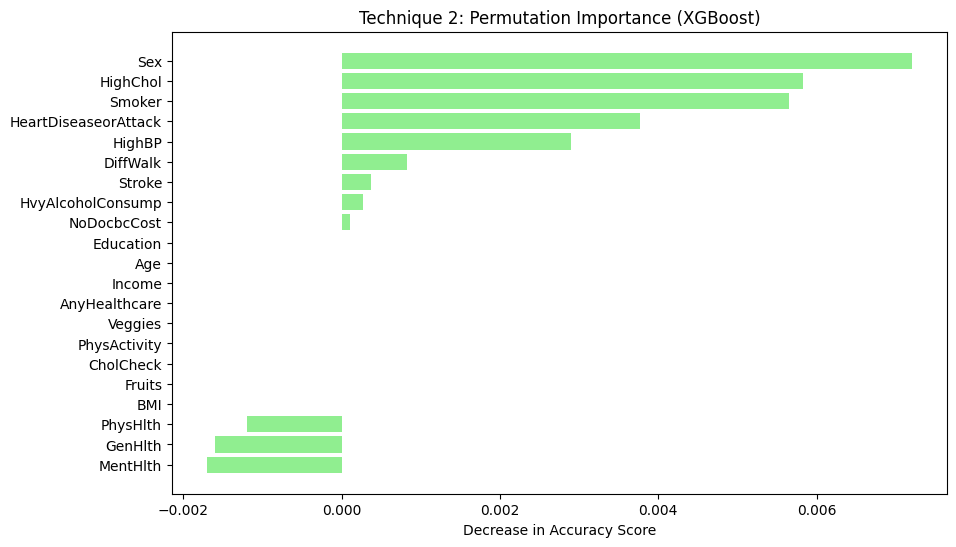

In [78]:
# 2. Permutation Importance
# Measures how much the model accuracy drops when a feature's values are shuffled
perm_result = permutation_importance(xgb_model, X_test_scaled, y_test, n_repeats=10, random_state=42)
sorted_idx = perm_result.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.barh(X.columns[sorted_idx], perm_result.importances_mean[sorted_idx], color='lightgreen')
plt.title("Technique 2: Permutation Importance (XGBoost)")
plt.xlabel("Decrease in Accuracy Score")
plt.show()

PDP

### Interpretation:
- PDP shows the **average effect** of a feature on the model output
- It helps understand how predictions change when a feature value changes
- Useful for identifying non-linear trends and thresholds

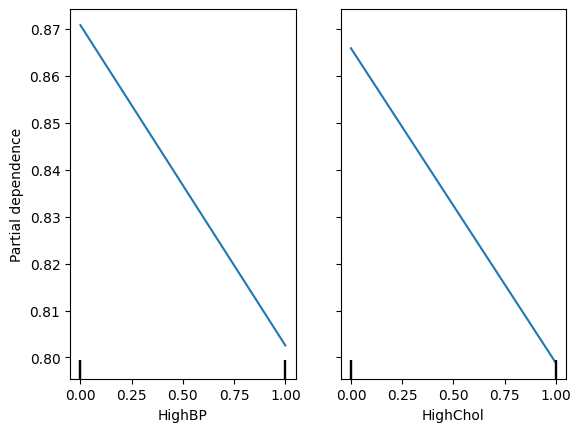

In [93]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features = [0, 1]  # feature indices

PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features,
    target=0  # 👈 IMPORTANT (choose class index)
)

plt.show()

LIME (Local Explanation)

## LIME (Local Interpretable Model-agnostic Explanations)

LIME is used to explain individual predictions made by the model.

It works by approximating the complex model locally around a specific data point using a simple interpretable model (such as linear regression).

###  Purpose:
- Explain a single prediction (local interpretability)
- Identify which features influenced a specific decision

###  Key Idea:
- Generate perturbed samples around an instance
- Get predictions from the trained model
- Fit a simple model locally to approximate behavior

### Output:
- Feature contributions for one prediction
- Positive values → support prediction
- Negative values → oppose prediction

In [91]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X.columns,
    class_names=['Class 0', 'Class 1'],
    mode='classification'
)

exp = explainer.explain_instance(
    X_test.values[0],
    model.predict_proba
)

exp.show_in_notebook()

Feature Importance (Built-in)

##  Feature Importance (Built-in - Tree Models)

Some models like XGBoost provide built-in feature importance based on how often and how effectively features are used in decision splits.

###  Purpose:
- Identify which features the model relies on most

### ⚙️ Key Idea:
- Based on how frequently a feature is used in splitting
- Or how much it reduces impurity

###  Output:
- Bar chart of feature importance
- Fast and simple interpretation method

###  Limitation:
- Does not show direction of impact
- Less detailed than SHAP or LIME

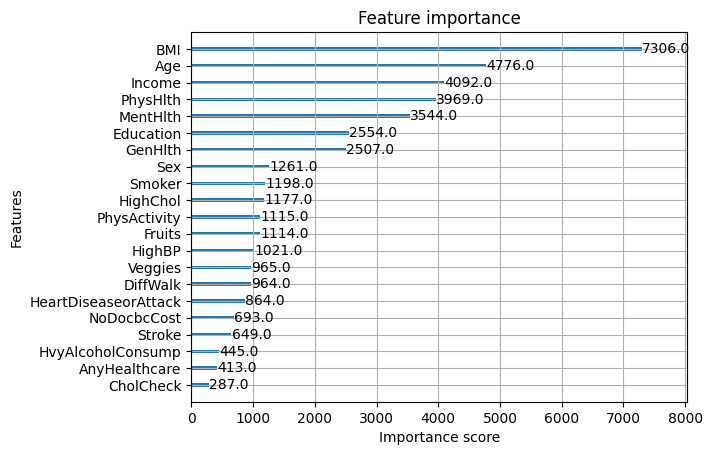

In [85]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model)
plt.show()

6. Permutation Importance

##  Permutation Feature Importance

Permutation importance measures feature relevance by evaluating the decrease in model performance when a feature’s values are randomly shuffled.

###  Purpose:
- Measure how much each feature contributes to model performance

###  Key Idea:
- Shuffle one feature at a time
- Observe drop in accuracy or performance
- Larger drop → more important feature

### Output:
- Ranked list of important features
- Model-agnostic method (works with any model)

In [86]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test, y_test, n_repeats=10)

for i in result.importances_mean.argsort()[::-1]:
    print(X.columns[i], result.importances_mean[i])

BMI 0.007324999999999959
GenHlth 0.005224999999999957
HighChol 0.0038499999999999646
HighBP 0.003349999999999942
HvyAlcoholConsump 0.0010499999999999733
Sex 0.0007999999999999452
Age 0.0006999999999999562
AnyHealthcare 0.0005999999999999561
Smoker 0.00039999999999996706
PhysActivity -0.00012500000000003063
Income -0.00022500000000003073
CholCheck -0.0002750000000000252
NoDocbcCost -0.00027500000000003634
HeartDiseaseorAttack -0.0006000000000000449
Education -0.0011000000000000564
MentHlth -0.0012750000000000595
Fruits -0.0017500000000000404
Veggies -0.0017750000000000376
Stroke -0.0018500000000000517
DiffWalk -0.002100000000000035
PhysHlth -0.0030500000000000306


SHAP Explainability (Very Important)

SHAP is a powerful method based on game theory that explains the contribution of each feature to the model’s prediction.

It provides both global and local interpretability.

### Purpose:
- Understand feature impact on predictions
- Explain both individual and overall model behavior

### Key Idea:
- Each feature is treated as a "player" in a game
- SHAP values represent each feature’s contribution to the final prediction

###Output:
- Global feature importance (summary plot)
- Local explanation for individual predictions
- Direction of impact (positive or negative)

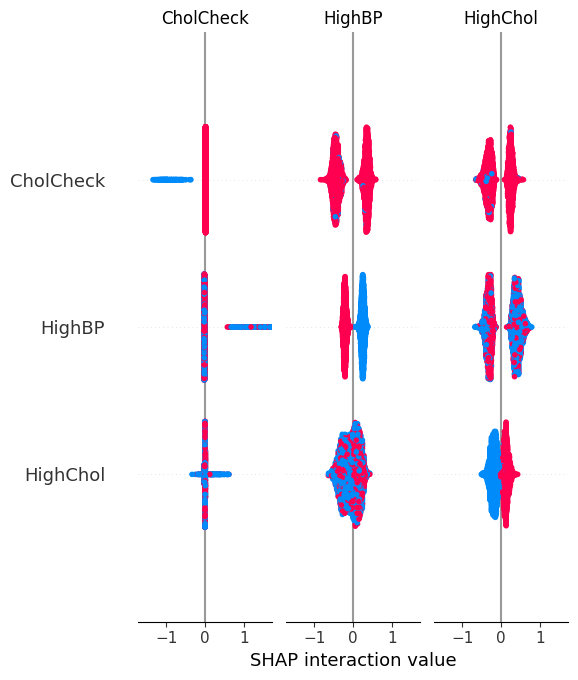

In [83]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)